In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             mean_absolute_percentage_error)
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
data = pd.read_excel("data/Timeseries_data.xlsx")
data["Date"] = pd.to_datetime(data["Date"])

In [4]:
def plot_time_series_data(dates: np.array, values: np.array, title: str) -> None:
    fig, _ = plt.subplots()
    fig.set_figheight(8)
    fig.set_figwidth(12)
    plt.plot(dates, values)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

There are significant yearly outliers in our data:

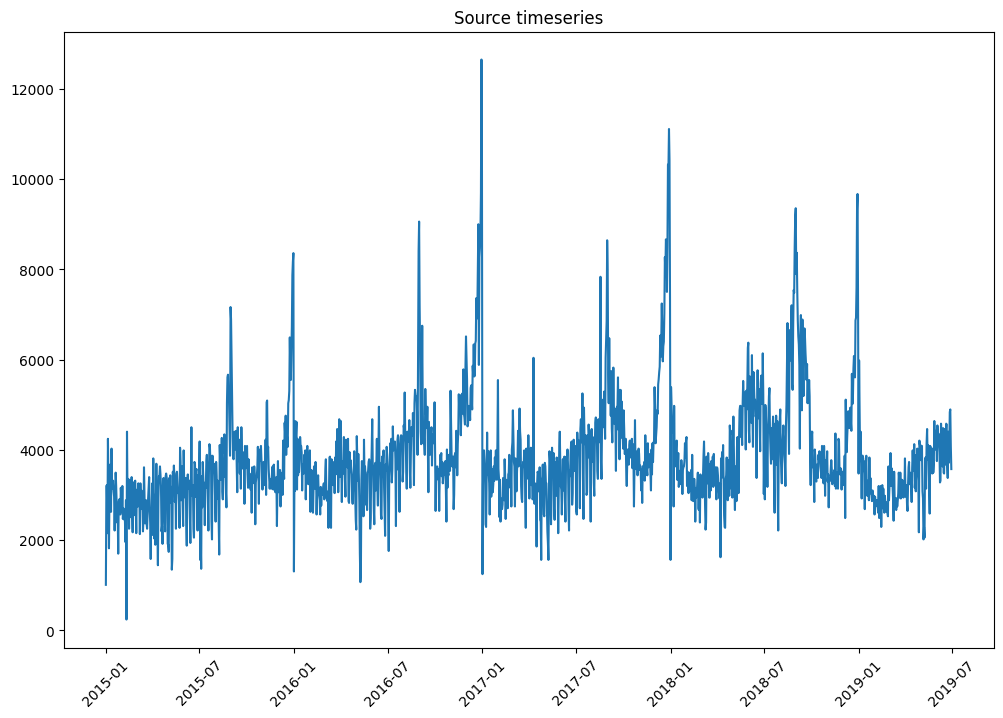

In [5]:
plot_time_series_data(dates=data["Date"], values=data["series1"], title="Source timeseries")

In [6]:
def adf_test(timeseries: pd.Series) -> None:
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    print(f"Test Statistic {dftest[0]}")
    print(f"p-value {dftest[1]}")
    print(f"Critical value 5% {dftest[4]["5%"]}")

In [7]:
adf_test(data["series1"])

Results of Dickey-Fuller Test:
Test Statistic -5.496713808722659
p-value 2.1154012725976856e-06
Critical value 5% -2.8633257585414


In [8]:
def kpss_test(timeseries: pd.Series) -> None:
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    print(f"Test Statistic {kpsstest[0]}")
    print(f"p-value {kpsstest[1]}")
    print(f"Critical value 5% {kpsstest[3]["5%"]}")

In [9]:
kpss_test(data["series1"])

Results of KPSS Test:
Test Statistic 0.8071872591261903
p-value 0.01
Critical value 5% 0.463


/tmp/ipykernel_11263/110362314.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


ADF test showed that our data is stationary, KPSS test that it is not. We should substract series from itself with lag of 1.

In [10]:
data["series_diff"] = data["series1"].diff()
data = data.dropna()

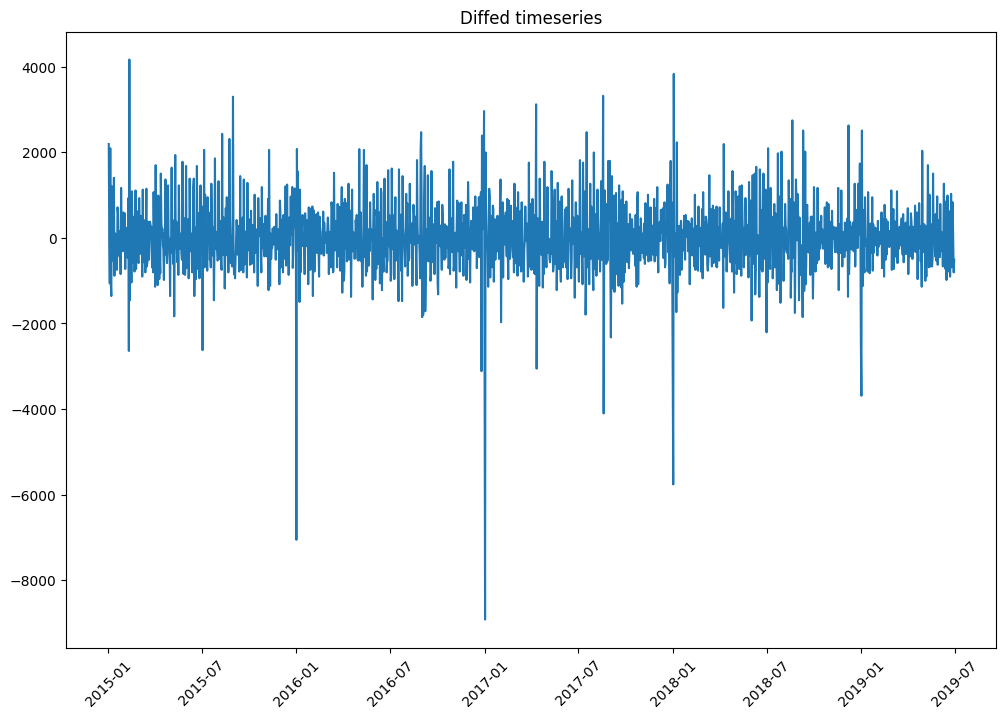

In [11]:
plot_time_series_data(dates=data["Date"], values=data["series_diff"], title="Diffed timeseries")

In [12]:
adf_test(data["series_diff"])

Results of Dickey-Fuller Test:
Test Statistic -10.51156491015503
p-value 1.0213243860308981e-18
Critical value 5% -2.8633257585414


In [13]:
kpss_test(data["series_diff"])

Results of KPSS Test:
Test Statistic 0.09083670632725886
p-value 0.1
Critical value 5% 0.463


/tmp/ipykernel_11263/110362314.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


Now both tests are saying that series is stationary. We should use d=1 while SARIMA training.

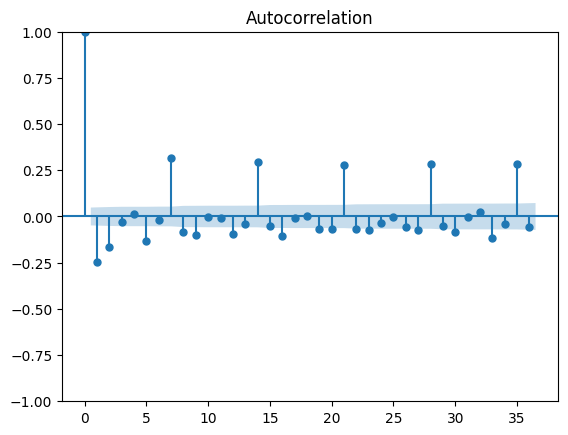

In [14]:
plot_acf(data['series_diff'], lags=36)
plt.show()

You can see that we have strong autocorrelation with lag 7. There is a weekly seasonality in our data.

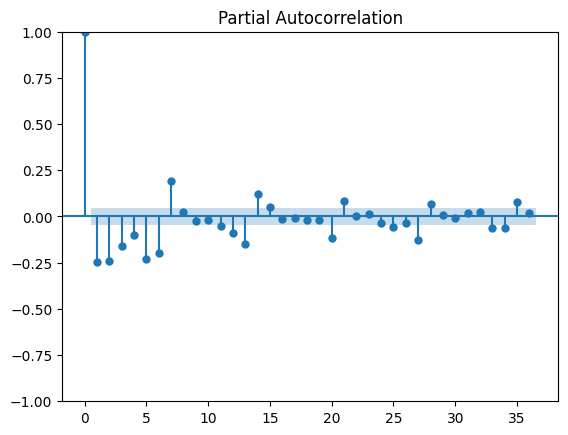

In [15]:
plot_pacf(data['series_diff'], lags=36)
plt.show()

Extracting last three monthes for test.

In [16]:
train =  data[data["Date"] < '2019-04-01'].reset_index()
test = data[data["Date"] >= '2019-04-01'].reset_index()
forecast_steps = test.shape[0]

Clipping ouliers to 0.99 quantile.

In [17]:
upper_limit = train['series1'].quantile(0.99)
train['series1'] = train['series1'].clip(upper=upper_limit)

Scaling our data

In [18]:
scaler = StandardScaler()
train["series1"] = scaler.fit_transform(train["series1"].values.reshape(-1, 1))

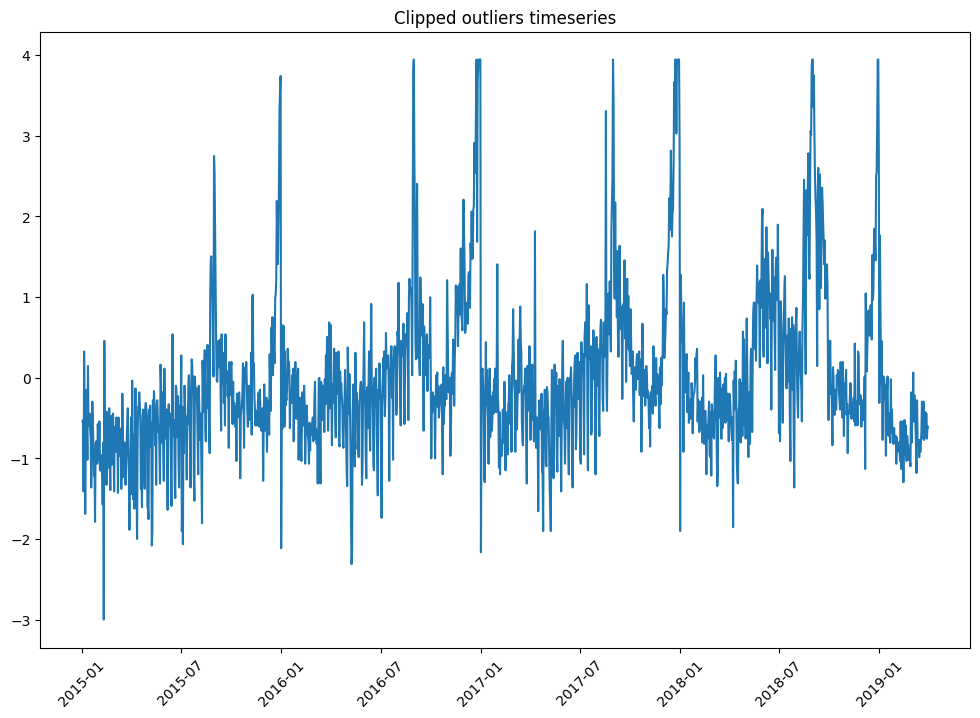

In [19]:
plot_time_series_data(dates=train["Date"], values=train["series1"], title="Clipped outliers timeseries")

Finding optimal orders for SARIMA model

In [ ]:
model = auto_arima(train['series1'], 
                  seasonal=True, 
                  m=7,
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(model.summary())

One step ahead forecast with SARIMA:

In [ ]:
sarima_forecast = []
test_np = test["series1"].to_numpy()

p,d,q = 1,1,1
P,D,Q,s = 1,0,1,7 

for i in range(forecast_steps):
  cut_point = train.shape[0] - forecast_steps + i

  model = SARIMAX(train["series1"][:cut_point],
                  order=(p, d, q),
                  seasonal_order=(P, D, Q, s),
                  measurement_error=True)
  
  model_fit = model.fit(disp=False, method_kwargs={'maxiter':500})
  sarima_forecast.append(model_fit.predict(cut_point).values[0])

In [68]:
def plot_forecast(actual: np.array, forecast: np.array, dates: np.array, title: str) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(dates, actual, label='Actual')
    plt.plot(dates, forecast, label='Forecast')
    plt.title(title)
    plt.legend()
    plt.show()

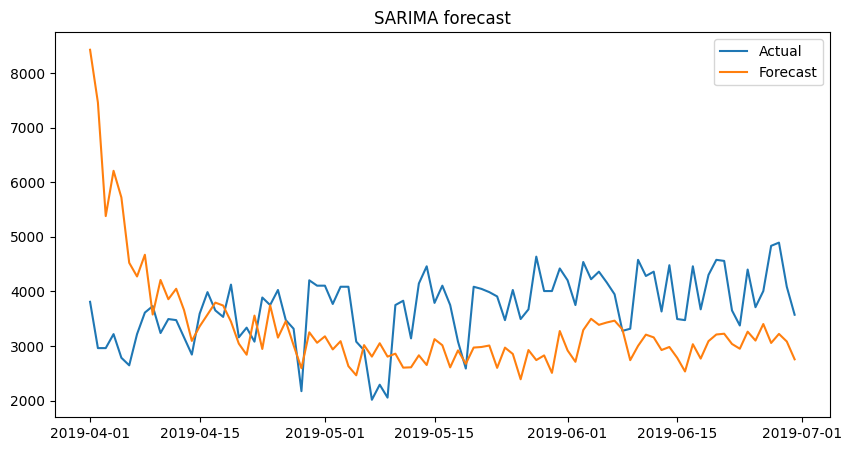

In [69]:
sarima_forecast = scaler.inverse_transform(np.array(sarima_forecast).reshape(-1, 1))
plot_forecast(test["series1"].to_numpy(), sarima_forecast, test["Date"].to_numpy(), "SARIMA forecast")

In [70]:
def compute_metrics(target: np.array, forecast: np.array) -> None:
    print(f"MAE: {mean_absolute_error(target, forecast)}")
    print(f"MSE: {mean_squared_error(target, forecast)}")
    print(f"MAPE {mean_absolute_percentage_error(target, forecast)}")

In [71]:
compute_metrics(test["series1"].to_numpy(), sarima_forecast)

MAE: 1002.6638742964662
MSE: 1610730.8054733952
MAPE 0.2736706856847449


Preprocessing data for facebook prophet training

In [72]:
prophet_train = train[["series1", "Date"]]
prophet_train = prophet_train.rename(columns={"series1": "y", "Date": "ds"})

prophet_test = test[["series1", "Date"]]
prophet_test = prophet_test.rename(columns={"series1": "y", "Date": "ds"})

In [73]:
model = Prophet()
model.fit(prophet_train)

future = model.make_future_dataframe(periods=forecast_steps)

prophet_forecast = model.predict(prophet_test)["yhat"]

08:08:34 - cmdstanpy - INFO - Chain [1] start processing
08:08:34 - cmdstanpy - INFO - Chain [1] done processing


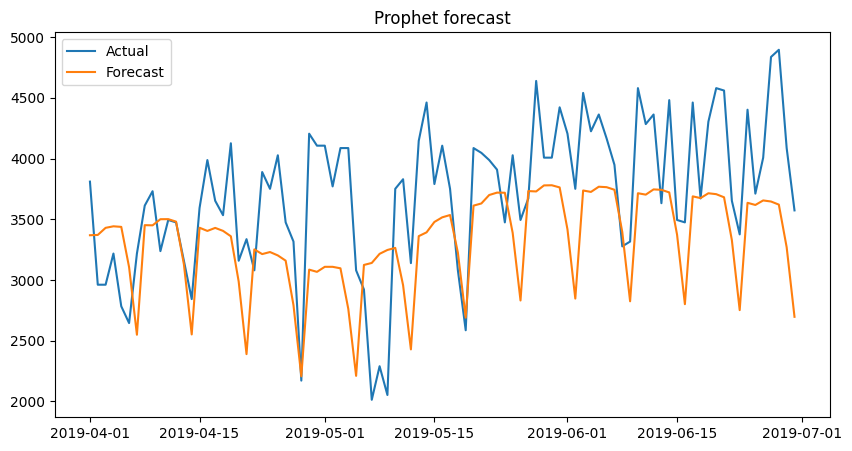

In [74]:
prophet_forecast = scaler.inverse_transform(np.array(prophet_forecast).reshape(-1, 1))
plot_forecast(test["series1"].to_numpy(), prophet_forecast, test["Date"].to_numpy(), "Prophet forecast")

In [75]:
compute_metrics(test["series1"].to_numpy(), prophet_forecast)

MAE: 539.8036452957105
MSE: 406632.6236698481
MAPE 0.14702082886117687


In [78]:
one_step_forecast = []
prophet_test["y"] = scaler.transform(prophet_test["y"].to_numpy().reshape(-1, 1))

for i in range(forecast_steps):
    train = pd.concat([prophet_train, prophet_test.iloc[:i]])
    test_row = prophet_train.iloc[i]
    
    model = Prophet()
    model.fit(train)
    
    future = model.make_future_dataframe(periods=1, include_history=False)
    
    forecast = model.predict(future)
    one_step_forecast.append(forecast['yhat'].values[0])

08:25:06 - cmdstanpy - INFO - Chain [1] start processing
08:25:06 - cmdstanpy - INFO - Chain [1] done processing
08:25:06 - cmdstanpy - INFO - Chain [1] start processing
08:25:07 - cmdstanpy - INFO - Chain [1] done processing
08:25:07 - cmdstanpy - INFO - Chain [1] start processing
08:25:07 - cmdstanpy - INFO - Chain [1] done processing
08:25:07 - cmdstanpy - INFO - Chain [1] start processing
08:25:07 - cmdstanpy - INFO - Chain [1] done processing
08:25:07 - cmdstanpy - INFO - Chain [1] start processing
08:25:08 - cmdstanpy - INFO - Chain [1] done processing
08:25:08 - cmdstanpy - INFO - Chain [1] start processing
08:25:08 - cmdstanpy - INFO - Chain [1] done processing
08:25:08 - cmdstanpy - INFO - Chain [1] start processing
08:25:08 - cmdstanpy - INFO - Chain [1] done processing
08:25:08 - cmdstanpy - INFO - Chain [1] start processing
08:25:08 - cmdstanpy - INFO - Chain [1] done processing
08:25:09 - cmdstanpy - INFO - Chain [1] start processing
08:25:09 - cmdstanpy - INFO - Chain [1]

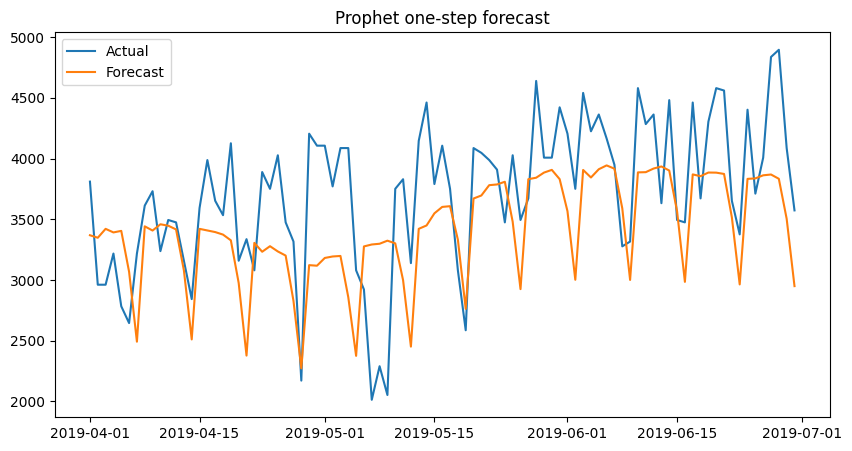

In [79]:
one_step_forecast = scaler.inverse_transform(np.array(one_step_forecast).reshape(-1, 1))
plot_forecast(test["series1"].to_numpy(), one_step_forecast, test["Date"].to_numpy(), "Prophet one-step forecast")

In [80]:
compute_metrics(test["series1"].to_numpy(), one_step_forecast)

MAE: 485.07412650253633
MSE: 329769.2804444912
MAPE 0.13515126497907537


As you can see the best results showed prophet with one step ahead forecasting.

In [ ]:
prophet_full = data[["series1", "Date"]]
prophet_full = prophet_full.rename(columns={"series1": "y", "Date": "ds"})

In [ ]:
model = Prophet()
model.fit(prophet_full)

future = model.make_future_dataframe(periods=91)

prophet_forecast = model.predict(prophet_test)["yhat"]

In [ ]:
results = pd.Series(prophet_forecast)
results.to_excel("data/Task1_forecast.xlsx")